**This notebook shows how to run PolyLayout on Aria Synthetic Environments and ScanNet++ v2.**

In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import torch
from omegaconf import OmegaConf
import rerun as rr
import rerun.blueprint as rrb

from pixloc.pixlib.datasets.ase import ASE
from pixloc.pixlib.datasets.scannetpp import ScanNet
from pixloc.pixlib.datasets.edge_rendering import EdgeRenderer
from pixloc.pixlib.datasets.view import numpy_image_to_torch
from pixloc.pixlib.utils.tensor import batch_to_device, map_tensor
from pixloc.pixlib.utils.experiments import load_experiment
from pixloc.visualization.viz_2d import (
    plot_images, plot_keypoints, features_to_RGB, add_text)
from pixloc.visualization.rerun import (
    log_camera, log_image, log_layout, log_mesh, log_points)

os.environ['RERUN_NOTEBOOK_ASSET'] = 'inline'
torch.set_grad_enabled(False);
color_pred = np.array([60, 180, 75]) / 255.
color_gt = np.array([0, 130, 200]) / 255.

# Create a dataloader

### Aria Synthetic Environments

In [2]:
conf = {
    'num_views': 10,
    'resize': 512,
    'read_line_segments': True,
    'read_pointcloud': True,
    'init_layout': 'polygon_hull',
    'batch_size': None,
    'seed': 1,
    'num_workers': 0,
}
split = 'test' # 'val'
loader = ASE(conf).get_data_loader(split, shuffle=True)

[08/03/2026 11:17:19 pixloc.pixlib.datasets.base_dataset INFO] Creating dataset ASE


### ScanNet++

In [ ]:
conf = {
    'num_views': 10,
    'max_num_points3D': 256,
    'resize': 512,
    'resize_by': 'min',
    'init_layout': 'polygon_hull',
    'read_line_segments': True,
    'read_pointcloud': True,
    'batch_size': None,
    'seed': 1,
    'num_workers': 0,
}
split = 'multi_room'
loader = ScanNet(conf).get_data_loader(split, shuffle=True)

# Load the training experiment

In [3]:
# Name of the example experiment. Replace with your own training experiment.
exp = 'polylayout_scannetpp_fine_tuned'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
conf = {
    'pre_optimize_vp': True,
    'vp_opt_cam_margin': 3.0,
    'split_layout_thr': 1.0,
    'optimizer': {
        'name': 'multi_room_optimizer',
        'shared_floor': True,
        'shared_ceiling': True,
        'num_iters': 15,
        'edge_cost_scale': 0.05,
        'vp_cost_scale': 40.0,
        'perimeter_cost_scale': [0.0, 0.0005, 0.0005],
        'clamp_dd': 0.5,
        'simplify_layout_dd_thr': 0.05,
    },
}
refiner = load_experiment(exp, conf).to(device)
print(OmegaConf.to_yaml(refiner.conf))

[08/03/2026 11:17:19 pixloc.pixlib.utils.experiments INFO] Loading checkpoint checkpoint_best.tar


name: layout_refiner
trainable: true
freeze_batch_normalization: false
extractor:
  name: dinov2
  output_scales:
  - 0
  - 2
  - 4
  num_tokens: 1225
  checkpointed: true
optimizer:
  name: multi_room_optimizer
  num_iters: 15
  loss_fn: scaled_barron(0, 0.1)
  edge_cost_scale: 0.05
  num_edge_points: 40
  clamp_dd: 0.5
  shared_floor: true
  shared_ceiling: true
  vp_cost_scale: 40.0
  perimeter_cost_scale:
  - 0.0
  - 0.0005
  - 0.0005
  simplify_layout_dd_thr: 0.05
duplicate_optimizer_per_scale: true
success_thresh: 3
clamp_error: 50
normalize_features: true
normalize_dt: true
init_target_offset: null
pre_optimize_vp: true
vp_opt_dist_thr:
- 1
- 0.5
- 0.25
- 0.125
- 0.0625
vp_opt_cam_margin: 3.0
vp_opt_pixel_size: 1.0
vp_opt_num_points_quadrant: null
point_sampling: guided
num_points2D: 256
guided_sampling_exp: 4.0
split_layout_thr: 1.0
split_layout_max_walls: 30



# Run on a an example

### Run PolyLayout

In [4]:
# Setup logging function to store the optimization steps
layout_opt = []
for i in range(len(refiner.extractor.scales)):
    opt = refiner.optimizer[i] if refiner.conf.duplicate_optimizer_per_scale else refiner.optimizer
    opt.logging_fn = lambda **args: layout_opt.append(args['layout'].detach().cpu())

# Run the layout refiner
data = next(iter(loader))
data = batch_to_device(data, device)
pred = refiner(data)

data = batch_to_device(data, "cpu")
pred = batch_to_device(pred, "cpu")

Loaded trajectory with 1166 device poses.
Loaded #3dPoints: 2064513


### Visualize inputs

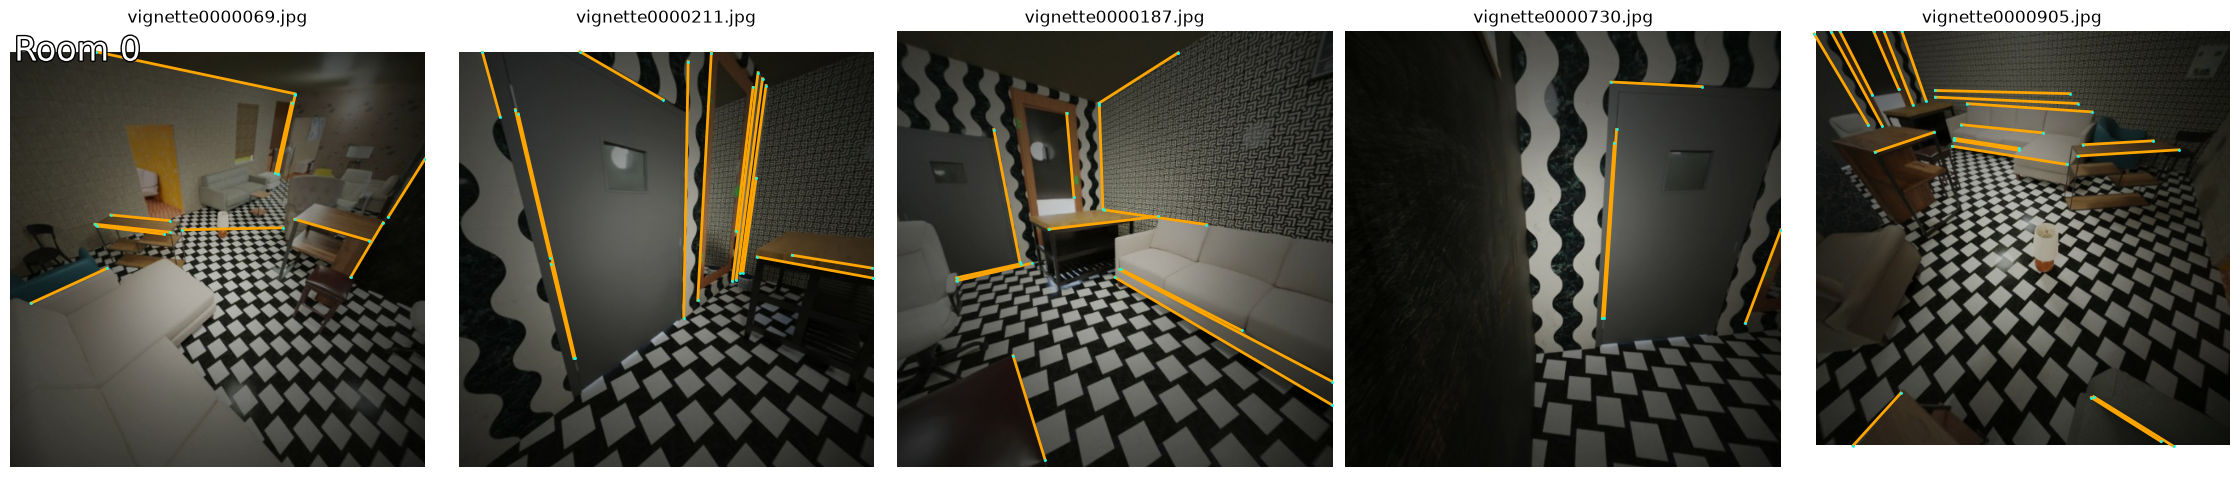

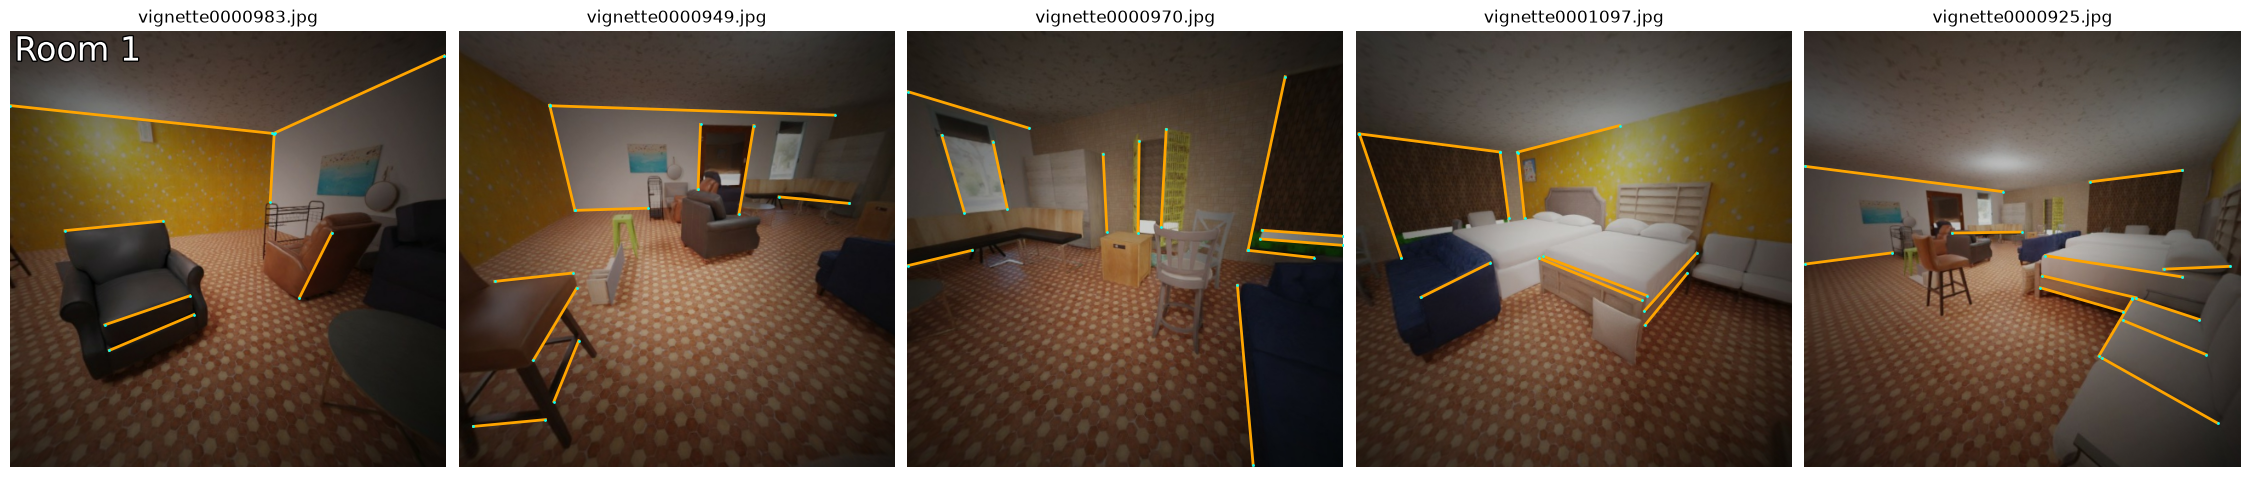

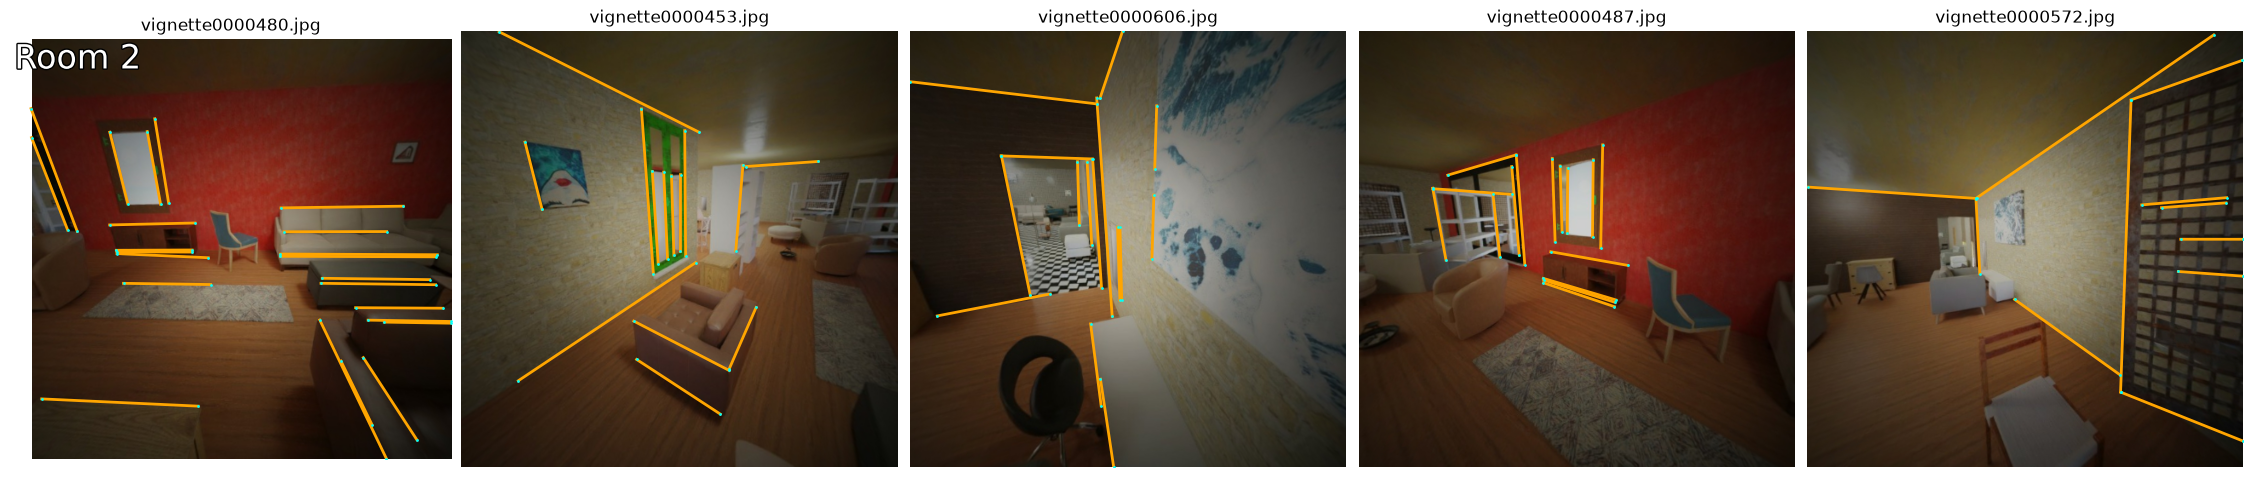

In [5]:
num_rooms, num_views, _, height, width = data['image'].shape
num_views_to_show = num_views // 2

for i in range(num_rooms):
    images, titles, keypoints, lines = [], [], [], []

    for j in range(num_views_to_show):
        images.append(data['image'][i, j].permute(1, 2, 0))
        titles.append(data['name'][j][i])

        if 'lines2D' in data:
            l2D = data['lines2D'][i, j][data['l2D_mask'][i, j]]
            lines.append(data['camera'][i, j].denormalize(l2D))

    plot_images(images, titles=titles)
    add_text(0, f'Room {i}', fs=24)
    plot_keypoints(keypoints)
    if 'lines2D' in data:
        try:
            from deeplsd.geometry.viz_2d import plot_lines
            plot_lines(lines, indices=list(range(num_views_to_show)))
        except ImportError:
            pass

### Visualize feature maps

In [ ]:
room = 0  # Visualize for first room
for i, (F, C) in enumerate(zip(pred['feature_maps'], pred['confidences'])):
    plot_images(features_to_RGB(*[f.numpy() for f in F[room, :num_views_to_show]]))
    add_text(0, f'Level {i}', fs=24)
    plot_images([c.permute(1, 2, 0) for c in C[room, :num_views_to_show]])

### Visualize layout prediction in 2D

/tmp/ipykernel_488535/2228679131.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return edge_map * image + (1.0 - edge_map) * torch.ones_like(image) * color[..., None, None]


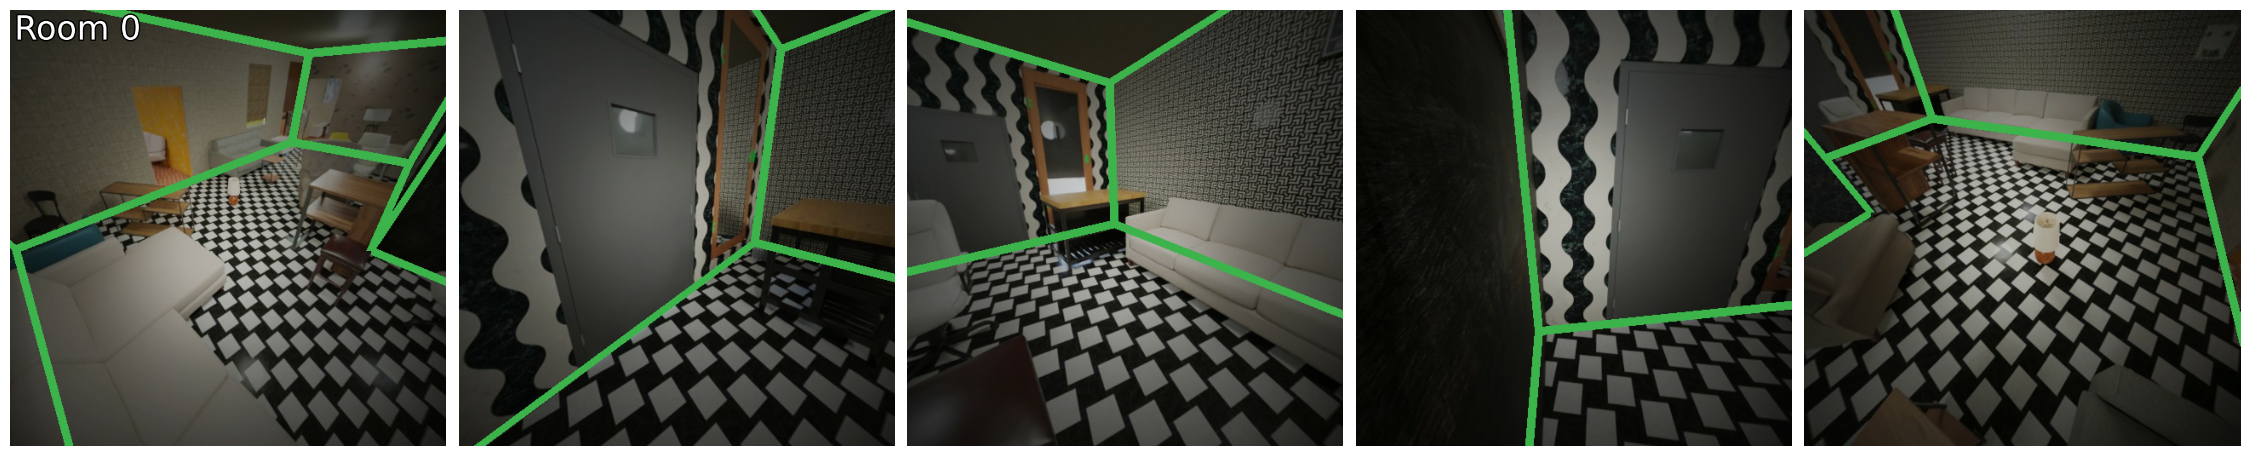

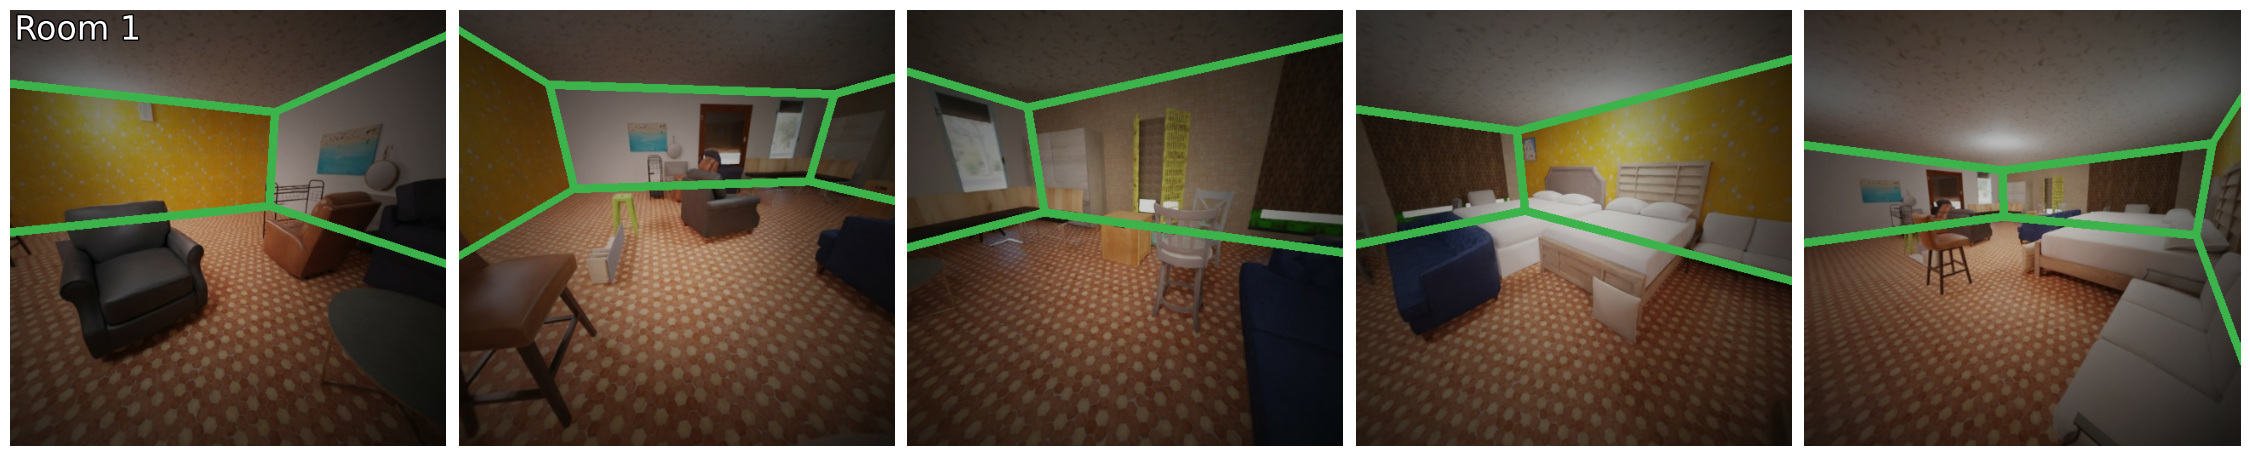

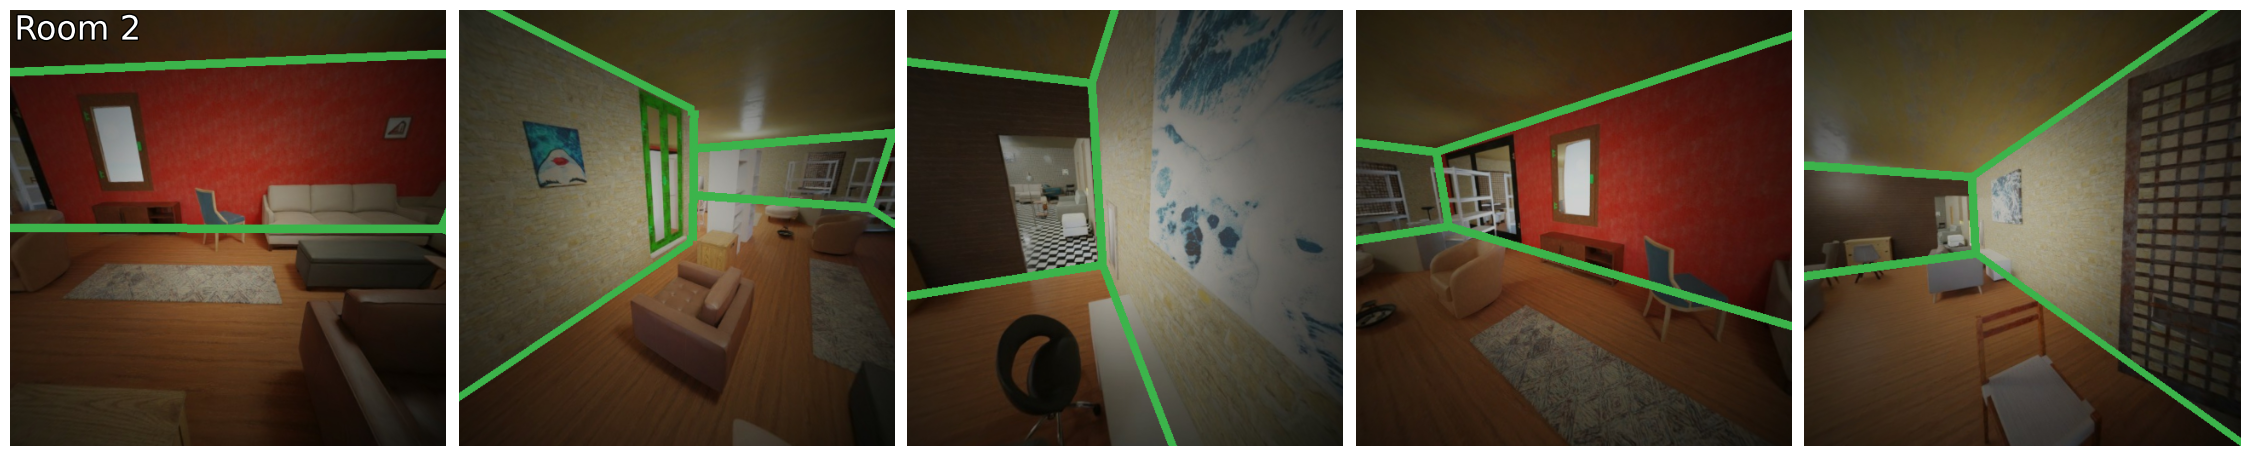

In [6]:
def mix_images(image, edge_map, color):
    return edge_map * image + (1.0 - edge_map) * torch.ones_like(image) * color[..., None, None]

renderer = EdgeRenderer(width, height)

for i in range(num_rooms):
    edge_images = []

    for j in range(num_views_to_show):
        img_edge = renderer.render(
            layout_opt[-1][i],
            data['camera'][i, j],
            data['T_w2cam'][i, j],
            10.0)
        img_edge = mix_images(
            data['image'][i, j],
            1.0 - numpy_image_to_torch(img_edge),
            color_pred)
        edge_images.append(img_edge.permute(1, 2, 0))

    plot_images(edge_images)
    add_text(0, f'Room {i}', fs=24)

### Visualize optimization steps in 3D

In [7]:
rr.init('PolyLayout demo')
rr.send_blueprint(rrb.Blueprint(rrb.Spatial3DView()))

rr.set_time('step', sequence=-1)

if 'pointcloud' in data:
    log_points('pointcloud', data['pointcloud'], colors=[255, 255, 255], radii=0.005)

for i in range(num_rooms):
    if 'layout_gt' in data:
        log_layout(f'room{i}/layout_gt', data['layout_gt'][i], color=color_gt)
    elif 'verts_gt' in data and 'faces_gt' in data:
        mask = ~torch.all(data['faces_gt'][i] == 0, dim=1)
        log_mesh(f'room{i}/mesh_gt', data['verts_gt'][i], data['faces_gt'][i][mask], albedo_factor=np.r_[color_gt, 0.5])

    for j in range(num_views):
        log_camera(f'room{i}/cam{j}', data['camera'][i, j], data['T_w2cam'][i, j], image_plane_distance=0.2)
        log_image(f'room{i}/cam{j}/img', data['image'][i, j].permute(1, 2, 0), opacity=0.9)

for i, layout in enumerate(layout_opt):
    rr.set_time('step', sequence=i)
    for j in range(layout.shape[0]):
        log_layout(f'room{j}/layout', layout[j], color=color_pred)

rr.notebook_show(width=1024, height=768)

Loading inline widget due to RERUN_NOTEBOOK_ASSET=inline
